# Modeling — ElasticNet baseline

Get this model fully fit, validated, and interpreted before touching CatBoost/RF
— a linear model that can be fully defended beats jumping straight to a
black-box one, and the tree models later reuse the exact same split, target
definition, and winsorization bounds locked in here.


In [22]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sys.path.insert(0, "../src")
from data_prep import load_and_clean

RANDOM_STATE = 42
L1_RATIOS = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
BLUE = "#2a78d6"
ORANGE = "#eb6834"

plt.rcParams["figure.facecolor"] = "white"

clean = load_and_clean("../data/survey.csv")
clean.shape


(4916, 54)

## 3.1 Split — 60/20/20 (train/test/val), stratified

Stratifying on a single quartile-binned key derived from `YearsCode` (99.6%
complete, the least missing of the three seniority proxies). `age_mid`/`WorkExp`
are 0.80–0.90 correlated with it (Pass B heatmap in the EDA notebook), so
balancing `YearsCode` across splits approximately balances them too, without
fragmenting into dozens of near-empty strata the way stratifying on all three
jointly would.

The median fill below is used **only** to compute the stratification key —
the real `YearsCode` feature column keeps its `NaN`s untouched.


In [23]:
strat_key = pd.qcut(
    clean["YearsCode"].fillna(clean["YearsCode"].median()),
    q=4,
    labels=False,
    duplicates="drop",
)

train_df, temp_df, strat_train, strat_temp = train_test_split(
    clean,
    strat_key,
    test_size=0.4,
    stratify=strat_key,
    random_state=RANDOM_STATE,
)
test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=strat_temp,
    random_state=RANDOM_STATE,
)

print(f"train: {train_df.shape}, test: {test_df.shape}, val: {val_df.shape}")
print(f"proportions: {len(train_df)/len(clean):.2%} / {len(test_df)/len(clean):.2%} / {len(val_df)/len(clean):.2%}")


train: (2949, 54), test: (983, 54), val: (984, 54)
proportions: 59.99% / 20.00% / 20.02%


## 3.2 Outlier handling — winsorize + flag, fit on train only

Replaces a fixed global salary floor/cap (the original approach) with bounds
computed strictly from `train`. These bounds are fixed once here and reused
everywhere downstream — never recomputed on `test`/`val`, and not recomputed
again at the train+test refit step in 3.6 — so the definition of "outlier"
never moves once it's set.

Alongside the winsorized `annual_salary_usd`/`log_salary`, this also keeps
`annual_salary_usd_raw`/`log_salary_raw` (the true, unclipped values) — both
are needed for the full metrics breakdown in 3.7.


In [24]:
p5 = train_df["annual_salary_usd"].quantile(0.05)
p95 = train_df["annual_salary_usd"].quantile(0.95)
print(f"train p5 = {p5:,.0f}, train p95 = {p95:,.0f}")


def winsorize_and_flag(df, p5, p95):
    df = df.copy()
    df["annual_salary_usd_raw"] = df["annual_salary_usd"]
    df["log_salary_raw"] = np.log1p(df["annual_salary_usd_raw"])
    df["salary_flag_low"] = (df["annual_salary_usd"] < p5).astype(int)
    df["salary_flag_high"] = (df["annual_salary_usd"] > p95).astype(int)
    df["annual_salary_usd"] = df["annual_salary_usd"].clip(p5, p95)
    df["log_salary"] = np.log1p(df["annual_salary_usd"])
    return df


train_df = winsorize_and_flag(train_df, p5, p95)
test_df = winsorize_and_flag(test_df, p5, p95)
val_df = winsorize_and_flag(val_df, p5, p95)

for name, df in [("train", train_df), ("test", test_df), ("val", val_df)]:
    n_flagged = df["salary_flag_low"].sum() + df["salary_flag_high"].sum()
    print(f"{name}: {n_flagged} flagged / {len(df)} ({n_flagged / len(df):.1%})")


train p5 = 3,653, train p95 = 232,029
train: 295 flagged / 2949 (10.0%)
test: 102 flagged / 983 (10.4%)
val: 74 flagged / 984 (7.5%)


## 3.3 Feature engineering — interaction and self-interaction terms

Built as plain numeric products of (numeric or binarized-indicator) pairs —
deliberately **not** full categorical cross-products (e.g. `EdLevel × DevType`
one-hot), since that reintroduces the cardinality-explosion problem already
flagged when sizing `TOP_N_COUNTRIES`/`TOP_N_DEVTYPES`: `EdLevel`(~8) ×
`DevType`(~11) ≈ 88 mostly-rare columns off a ~2,950-row train set. Every term
below is instead exactly one new numeric column with one interpretable
coefficient.

The derived binary indicators (`is_manager`, `is_remote`, `has_advanced_degree`,
`is_usa`) are intermediate variables only, used to build the interactions — they
are **not** added as standalone model features, since that information is
already fully captured by the `ICorPM`/`RemoteWork`/`EdLevel`/`country_grouped`
one-hot encodings, and adding both would just be redundant duplication.

Eleven terms:
1. `YearsCode × num_languages` — does polyglot breadth pay off more for the experienced?
2. `YearsCode × num_databases` — same idea for database breadth
3. `WorkExp × is_manager` — does the experience premium steepen once you're managing people?
4. `is_manager × orgsize_mid` — does the management premium scale with org size?
5. `is_remote × YearsCode` — do senior people extract a bigger remote-work premium/penalty than juniors?
6. `has_advanced_degree × num_languages` — does an advanced degree amplify the payoff of technical breadth?
7. `is_usa × has_advanced_degree` — does a US-market advanced degree earn more than the sum of its parts?
8. `WorkExp × is_usa` — is the return to professional experience steeper specifically in the US market?
9. `log_workexp` (`= log1p(WorkExp)`) — the Pass B functional-form plots (`01_eda.ipynb`)
   showed `WorkExp`/`YearsCode`/`age_mid` all sharing the same steep-rise-then-plateau
   shape against `log_salary` (the classic Mincer equation pattern). A **squared**
   term would trace a parabola that eventually curves back down — not what the
   plot showed, which keeps rising, just slower — so `log1p(WorkExp)` is the closer
   shape match. Only `WorkExp` gets this treatment (not `YearsCode`/`age_mid` too),
   to avoid double-counting the same seniority signal across three collinear proxies.
10. `log_workexp × is_manager` and
11. `log_workexp × is_usa` — the log-transformed alternatives to terms 3 and 8.
    Raw `WorkExp` and `log(WorkExp)` are monotonic transforms of the *same*
    variable, so these two will correlate with their raw-form counterparts — but
    that's a functional-form question (which shape of `WorkExp` matters more for
    each interaction), not the same problem as `WorkExp` vs `YearsCode` vs
    `age_mid` being three separate variables proxying for one construct. Keeping
    both forms and letting ElasticNet's L1 penalty zero out whichever doesn't earn
    its coefficient is a standard way to do functional-form selection rather than
    asserting the answer upfront — the full coefficient table in 3.9 shows directly
    which form (or mix) survives.


In [25]:
def add_interactions(df):
    df = df.copy()
    is_manager = (df["ICorPM"] == "People manager").astype(int)
    is_remote = (df["RemoteWork"] == "Remote").astype(int)
    has_advanced_degree = (
        df["EdLevel"].str.contains("Master", na=False)
        | df["EdLevel"].str.contains("Professional degree", na=False)
    ).astype(int)
    is_usa = (df["country_grouped"] == "United States of America").astype(int)
    log_workexp = np.log1p(df["WorkExp"])

    df["yearscode_x_num_languages"] = df["YearsCode"] * df["num_languages"]
    df["yearscode_x_num_databases"] = df["YearsCode"] * df["num_databases"]
    df["workexp_x_is_manager"] = df["WorkExp"] * is_manager
    df["is_manager_x_orgsize"] = is_manager * df["orgsize_mid"]
    df["is_remote_x_yearscode"] = is_remote * df["YearsCode"]
    df["has_advdeg_x_num_languages"] = has_advanced_degree * df["num_languages"]
    df["is_usa_x_has_advdeg"] = is_usa * has_advanced_degree
    df["workexp_x_is_usa"] = df["WorkExp"] * is_usa
    df["log_workexp"] = log_workexp
    df["log_workexp_x_is_manager"] = log_workexp * is_manager
    df["log_workexp_x_is_usa"] = log_workexp * is_usa
    return df


train_df = add_interactions(train_df)
test_df = add_interactions(test_df)
val_df = add_interactions(val_df)

INTERACTION_COLS = [
    "yearscode_x_num_languages", "yearscode_x_num_databases",
    "workexp_x_is_manager", "is_manager_x_orgsize", "is_remote_x_yearscode",
    "has_advdeg_x_num_languages", "is_usa_x_has_advdeg", "workexp_x_is_usa",
    "log_workexp", "log_workexp_x_is_manager", "log_workexp_x_is_usa",
]
print(f"{len(INTERACTION_COLS)} interaction/self-interaction terms added")


11 interaction/self-interaction terms added


## 3.4 Feature encoding

- **Numeric (median-imputed, then scaled)**: continuous seniority/count features
  plus the 9 interaction terms above. `WorkExp`/`YearsCode`/`age_mid`/`orgsize_mid`
  all have some missingness (1.0%/0.4%/0.1%/~11% respectively) and, unlike
  CatBoost later, neither `StandardScaler` nor `ElasticNet` accepts `NaN` —
  median imputation is the simple, defensible choice for a linear baseline.
- **Binary (passthrough, already 0/1)**: the outlier flags and every `lang_*`/`db_*` column
- **Low/medium-cardinality categoricals (full one-hot, no dropped reference)**:
  small enough that ElasticNet's regularization handles the collinearity from a
  complete dummy set fine, and keeping every category is more interpretable
  than an implicit baseline
- **High-cardinality categoricals (top-N + "Other", already grouped in `data_prep.py`)**:
  `country_grouped`, `devtype_grouped`

`BASE_NUMERIC_COLS` and `INTERACTION_COLS` are kept as separate lists
specifically so 3.6 can run the identical pipeline with and without the
interaction terms — an ablation to isolate what they actually contribute,
rather than just asserting a richer feature set is better.


In [26]:
BASE_NUMERIC_COLS = ["WorkExp", "YearsCode", "age_mid", "orgsize_mid", "num_languages", "num_databases"]
SMALL_CAT_COLS = ["EdLevel", "Employment", "ICorPM", "RemoteWork", "Industry"]
BIG_CAT_COLS = ["country_grouped", "devtype_grouped"]
BINARY_COLS = ["salary_flag_low", "salary_flag_high"] + [
    c for c in clean.columns if c.startswith("lang_") or c.startswith("db_")
]

print(f"base numeric: {len(BASE_NUMERIC_COLS)}, +interactions: {len(BASE_NUMERIC_COLS) + len(INTERACTION_COLS)}")
print(f"categorical (pre-one-hot): {len(SMALL_CAT_COLS) + len(BIG_CAT_COLS)}, binary: {len(BINARY_COLS)}")


def make_preprocessor(numeric_cols):
    numeric_pipeline = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat_small", OneHotEncoder(handle_unknown="ignore"), SMALL_CAT_COLS),
            ("cat_big", OneHotEncoder(handle_unknown="ignore"), BIG_CAT_COLS),
            ("binary", "passthrough", BINARY_COLS),
        ]
    )


base numeric: 6, +interactions: 17
categorical (pre-one-hot): 7, binary: 34


## 3.5 Metrics helper — the full winsorized/raw × log/dollar breakdown

Four numbers for every evaluation, not two: `{log space, dollar space} ×
{winsorized target, raw target}`. Earlier draft only ever compared predictions
against the winsorized log target (in both the "winsorized" and "raw" print
blocks) — meaning the two log-space numbers were identical by construction, not
because winsorization is "effective in log space." `raw_log` below is the
missing cell: predictions compared against `log1p(annual_salary_usd_raw)`
directly, which actually tests that.

For **unflagged** rows, `winsorized == raw` exactly (winsorizing only touches
flagged rows), so those two columns will match there by definition — that's a
sanity check, not a finding.


In [27]:
def compute_all_metrics(pred_log, df_slice):
    def m(y_true, y_pred):
        return {
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
            "r2": r2_score(y_true, y_pred),
        }

    pred_dollars = np.expm1(pred_log)
    return {
        "winsorized_log": m(df_slice["log_salary"].values, pred_log),
        "raw_log": m(df_slice["log_salary_raw"].values, pred_log),
        "winsorized_dollar": m(df_slice["annual_salary_usd"].values, pred_dollars),
        "raw_dollar": m(df_slice["annual_salary_usd_raw"].values, pred_dollars),
    }


def report(pred_log, df_slice, label, verbose=True):
    metrics = compute_all_metrics(pred_log, df_slice)
    if verbose:
        print(f"--- {label} ({len(df_slice)} rows) ---")
        for key in ["winsorized_log", "raw_log", "winsorized_dollar", "raw_dollar"]:
            v = metrics[key]
            if "dollar" in key:
                print(f"  {key:18s} MAE=${v['mae']:>10,.0f}  RMSE=${v['rmse']:>10,.0f}  R2={v['r2']:.3f}")
            else:
                print(f"  {key:18s} MAE={v['mae']:.3f}       RMSE={v['rmse']:.3f}       R2={v['r2']:.3f}")
        print()
    return metrics


## 3.6 Staged fit: CV on train → test → refit on train+test → val

1. `ElasticNetCV` (5-fold CV *within* `train` only) selects `alpha`/`l1_ratio`,
   and the per-fold CV scores at that selection are reported directly — not just
   the winning hyperparameters, but how much they actually varied across folds.
2. Fit a plain `ElasticNet` with those hyperparameters on `train` alone, score
   on `test` — a genuine held-out check before `test` gets folded into anything.
3. Refit on `train + test` combined (same hyperparameters) for the final model,
   scored once on `val` — the one split nothing above has touched.

Wrapped in one function so 3.8 can run it twice (with/without interactions) for
the ablation without duplicating the whole pipeline.


In [28]:
def fit_and_evaluate(numeric_cols, label, verbose=True):
    feature_cols = numeric_cols + SMALL_CAT_COLS + BIG_CAT_COLS + BINARY_COLS
    if verbose:
        print(f"{'=' * 78}\n{label}: {len(feature_cols)} features ({len(numeric_cols)} numeric)\n{'=' * 78}\n")

    # --- CV on train only ---
    y_train = train_df["log_salary"].values
    prep_cv = make_preprocessor(numeric_cols)
    X_train_cv = prep_cv.fit_transform(train_df[feature_cols])

    enet_cv = ElasticNetCV(
        l1_ratio=L1_RATIOS,
        alphas=100,
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        max_iter=10_000,
    )
    enet_cv.fit(X_train_cv, y_train)

    l1_idx = int(np.argmin(np.abs(np.array(L1_RATIOS) - enet_cv.l1_ratio_)))
    alpha_idx = int(np.argmin(np.abs(enet_cv.alphas_[l1_idx] - enet_cv.alpha_)))
    fold_rmses = np.sqrt(enet_cv.mse_path_[l1_idx, alpha_idx, :])

    if verbose:
        print(f"CV-selected l1_ratio={enet_cv.l1_ratio_}, alpha={enet_cv.alpha_:.5f}")
        print(f"CV log-space RMSE at selected hyperparams: "
              f"{fold_rmses.mean():.3f} +/- {fold_rmses.std():.3f} across 5 folds "
              f"(per-fold: {np.round(fold_rmses, 3).tolist()})\n")

    # --- fit on train only, evaluate on test ---
    train_only_model = ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10_000)
    train_only_model.fit(X_train_cv, y_train)
    X_test = prep_cv.transform(test_df[feature_cols])
    test_pred_log = train_only_model.predict(X_test)
    test_metrics = report(test_pred_log, test_df, "TEST (model fit on train only)", verbose=verbose)

    # --- refit on train+test, evaluate on val (final, single check) ---
    train_test_df = pd.concat([train_df, test_df], axis=0)
    y_train_test = train_test_df["log_salary"].values
    prep_final = make_preprocessor(numeric_cols)
    X_train_test = prep_final.fit_transform(train_test_df[feature_cols])

    final_model = ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10_000)
    final_model.fit(X_train_test, y_train_test)

    X_val = prep_final.transform(val_df[feature_cols])
    val_pred_log = final_model.predict(X_val)
    val_metrics = report(val_pred_log, val_df, "VAL (final model, train+test refit)", verbose=verbose)

    flagged = (val_df["salary_flag_low"] == 1) | (val_df["salary_flag_high"] == 1)
    if verbose:
        print(f"{flagged.sum()} / {len(val_df)} val rows flagged as outliers\n")
    unflagged_metrics = report(val_pred_log[~flagged.values], val_df[~flagged], "VAL, NOT flagged", verbose=verbose)
    flagged_metrics = report(val_pred_log[flagged.values], val_df[flagged], "VAL, FLAGGED outliers", verbose=verbose)

    return {
        "label": label,
        "n_features": len(feature_cols),
        "l1_ratio": enet_cv.l1_ratio_,
        "alpha": enet_cv.alpha_,
        "cv_rmse_log_mean": fold_rmses.mean(),
        "cv_rmse_log_std": fold_rmses.std(),
        "test": test_metrics,
        "val": val_metrics,
        "val_unflagged": unflagged_metrics,
        "val_flagged": flagged_metrics,
        "model": final_model,
        "preprocessor": prep_final,
        "feature_cols": feature_cols,
    }


**Reading the flagged-vs-unflagged split below (once it runs):** if flagged
rows show a much larger dollar-space MAE than the rest, that's the concrete,
quantified version of "this model's weakness is extreme earners" — expected,
since the model was trained on winsorized values and was never asked to predict
a $600K salary precisely. Watch the new `raw_log` column here too: for flagged
rows specifically, `salary_flag_low`/`salary_flag_high` are both an input
feature *and* the literal definition of the winsorized target, so
`winsorized_log` R² for that subset will look unrealistically strong (the model
is mostly just sorting rows into two known constants); `raw_log` — compared
against the true, unclipped log-salary — is the honest read on whether the
model captures anything about *how* extreme a flagged row's real salary is,
beyond "probably high or low."


### 3.7 Baseline (no interactions)

In [29]:
baseline_results = fit_and_evaluate(BASE_NUMERIC_COLS, "BASELINE (no interactions)")


BASELINE (no interactions): 47 features (6 numeric)

CV-selected l1_ratio=0.5, alpha=0.00163
CV log-space RMSE at selected hyperparams: 0.602 +/- 0.023 across 5 folds (per-fold: [0.607, 0.56, 0.601, 0.629, 0.611])

--- TEST (model fit on train only) (983 rows) ---
  winsorized_log     MAE=0.400       RMSE=0.576       R2=0.701
  raw_log            MAE=0.532       RMSE=0.977       R2=0.603
  winsorized_dollar  MAE=$    27,521  RMSE=$    41,327  R2=0.548
  raw_dollar         MAE=$    35,672  RMSE=$    92,767  R2=0.302

--- VAL (final model, train+test refit) (984 rows) ---
  winsorized_log     MAE=0.417       RMSE=0.588       R2=0.658
  raw_log            MAE=0.477       RMSE=0.763       R2=0.652
  winsorized_dollar  MAE=$    29,696  RMSE=$    44,323  R2=0.487
  raw_dollar         MAE=$    35,244  RMSE=$    99,239  R2=0.248

74 / 984 val rows flagged as outliers

--- VAL, NOT flagged (910 rows) ---
  winsorized_log     MAE=0.417       RMSE=0.590       R2=0.513
  raw_log            MAE=0.4

### 3.8 With interaction/self-interaction terms

In [30]:
interaction_results = fit_and_evaluate(
    BASE_NUMERIC_COLS + INTERACTION_COLS, "WITH interactions (incl. log_workexp terms)"
)


WITH interactions (incl. log_workexp terms): 58 features (17 numeric)

CV-selected l1_ratio=1.0, alpha=0.00169
CV log-space RMSE at selected hyperparams: 0.585 +/- 0.023 across 5 folds (per-fold: [0.596, 0.545, 0.583, 0.616, 0.586])

--- TEST (model fit on train only) (983 rows) ---
  winsorized_log     MAE=0.390       RMSE=0.561       R2=0.716
  raw_log            MAE=0.521       RMSE=0.967       R2=0.611
  winsorized_dollar  MAE=$    26,097  RMSE=$    38,224  R2=0.613
  raw_dollar         MAE=$    34,098  RMSE=$    90,695  R2=0.333

--- VAL (final model, train+test refit) (984 rows) ---
  winsorized_log     MAE=0.397       RMSE=0.572       R2=0.677
  raw_log            MAE=0.458       RMSE=0.756       R2=0.658
  winsorized_dollar  MAE=$    27,346  RMSE=$    40,619  R2=0.569
  raw_dollar         MAE=$    33,459  RMSE=$    98,948  R2=0.253

74 / 984 val rows flagged as outliers

--- VAL, NOT flagged (910 rows) ---
  winsorized_log     MAE=0.397       RMSE=0.574       R2=0.539
  raw_log

### Ablation: did the interaction terms actually help?

Same split, same winsorization bounds, same CV grid — the only thing that
changes between the two runs above is whether the 9 engineered terms are in the
numeric feature list. This isolates their marginal contribution instead of just
reporting "the model with everything in it."


In [31]:
comparison = pd.DataFrame({
    "baseline": {
        "n_features": baseline_results["n_features"],
        "cv_rmse_log": baseline_results["cv_rmse_log_mean"],
        "val_r2_dollar_winsorized": baseline_results["val"]["winsorized_dollar"]["r2"],
        "val_mae_dollar_winsorized": baseline_results["val"]["winsorized_dollar"]["mae"],
        "val_r2_dollar_raw": baseline_results["val"]["raw_dollar"]["r2"],
        "val_mae_dollar_raw": baseline_results["val"]["raw_dollar"]["mae"],
        "val_r2_log_winsorized": baseline_results["val"]["winsorized_log"]["r2"],
    },
    "with_interactions": {
        "n_features": interaction_results["n_features"],
        "cv_rmse_log": interaction_results["cv_rmse_log_mean"],
        "val_r2_dollar_winsorized": interaction_results["val"]["winsorized_dollar"]["r2"],
        "val_mae_dollar_winsorized": interaction_results["val"]["winsorized_dollar"]["mae"],
        "val_r2_dollar_raw": interaction_results["val"]["raw_dollar"]["r2"],
        "val_mae_dollar_raw": interaction_results["val"]["raw_dollar"]["mae"],
        "val_r2_log_winsorized": interaction_results["val"]["winsorized_log"]["r2"],
    },
}).T
comparison


,n_features,cv_rmse_log,val_r2_dollar_winsorized,val_mae_dollar_winsorized,val_r2_dollar_raw,val_mae_dollar_raw,val_r2_log_winsorized
baseline,47.0,0.601514,0.487401,29695.896940,0.248444,35244.307186,0.657718
with_interactions,58.0,0.585213,0.569490,27345.932814,0.252843,33458.760346,0.676843


## 3.9 Full coefficient table (final model, with interactions)


In [32]:
feature_names = interaction_results["preprocessor"].get_feature_names_out()
final_coefs = pd.Series(interaction_results["model"].coef_, index=feature_names)
final_coefs_sorted = final_coefs.reindex(final_coefs.abs().sort_values(ascending=False).index)

print(f"{(final_coefs == 0).sum()} / {len(final_coefs)} coefficients zeroed out by regularization\n")

pd.set_option("display.max_rows", None)
coef_table = final_coefs_sorted.rename("coefficient").to_frame()
coef_table["abs_magnitude"] = coef_table["coefficient"].abs()
coef_table.to_csv("elasticnet_coefs_full.csv")
coef_table


43 / 123 coefficients zeroed out by regularization



,coefficient,abs_magnitude
binary__salary_flag_low,-2.301723,2.301723
cat_big__country_grouped_India,-0.780508,0.780508
cat_big__country_grouped_United States of America,0.668641,0.668641
cat_big__country_grouped_Switzerland,0.600221,0.600221
cat_big__country_grouped_Ukraine,-0.571639,0.571639
binary__salary_flag_high,0.560165,0.560165
cat_small__Employment_Student,-0.471215,0.471215
cat_big__country_grouped_Brazil,-0.457731,0.457731
num__log_workexp,0.368396,0.368396
cat_big__country_grouped_Other,-0.291054,0.291054


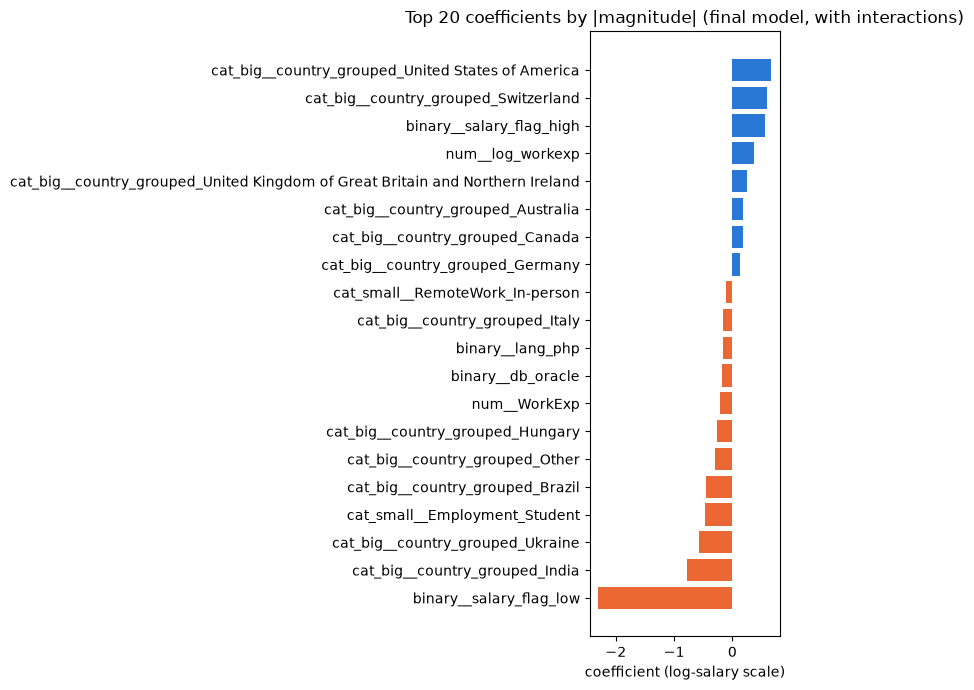

In [33]:
top_coefs = final_coefs_sorted.head(20).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors = [BLUE if v > 0 else ORANGE for v in top_coefs.values]
ax.barh(top_coefs.index, top_coefs.values, color=colors)
ax.set_xlabel("coefficient (log-salary scale)")
ax.set_title("Top 20 coefficients by |magnitude| (final model, with interactions)")
plt.tight_layout()
plt.show()


**Reading this:** blue bars push predicted salary up, orange bars pull it down,
both in log-salary units — a coefficient of `0.10` means roughly a 10% swing in
predicted salary, holding everything else constant. The full table above
(also written to `elasticnet_coefs_full.csv`) includes every feature, including
the ones regularization zeroed out entirely.
